## Imports

In [1]:
# cell 1 (Imports)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from datetime import datetime, timezone
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    classification_report,
    ConfusionMatrixDisplay,
)

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature
from mlflow.tracking import MlflowClient

plt.style.use("default")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

PROCESSED_DATA_PATH = ROOT / "data" / "processed" / "telco_customer_churn_clean.csv"
MODEL_PATH = ROOT / "artifacts" / "churn_model_package.joblib"

# MLflow setup

experiment_name = "churn_modeling"

MLFLOW_DB_PATH = ROOT / "mlflow.db"
ARTIFACT_PATH = ROOT / "mlruns"

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")

client = MlflowClient()

if client.get_experiment_by_name(experiment_name) is None:
    client.create_experiment(
        experiment_name,
        artifact_location=ARTIFACT_PATH.as_uri()
    )

mlflow.set_experiment(experiment_name)

2026/02/27 13:41:35 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/27 13:41:35 INFO mlflow.store.db.utils: Updating database tables


<Experiment: artifact_location='file:///c:/Users/arjun/OneDrive/Documents/GitHub/saas-churn-ml-system/mlruns', creation_time=1772179896669, experiment_id='1', last_update_time=1772179896669, lifecycle_stage='active', name='churn_modeling', tags={}, workspace='default'>

## Data Preparation & Splitting


In [2]:
# cell 2 (Data Preparation & Splitting)

df = pd.read_csv(PROCESSED_DATA_PATH)

TARGET = "Churn"

categorical_features = [
    col for col in df.select_dtypes(include="object").columns
    if col != TARGET
]

numeric_features = [
    col for col in df.select_dtypes(include=["number"]).columns
    if col != TARGET
]

print("Target:", TARGET)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# Train-Test Split (stratified)

X = df.drop(columns=[TARGET])
y = (df[TARGET] == "Yes").astype(int)

# 70 / 15 / 15 (stratified split)
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    drop="if_binary",
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Target: Churn
Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Train: (4922, 19)
Validation: (1055, 19)
Test: (1055, 19)

Train class distribution:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Validation class distribution:
Churn
0    0.733649
1    0.266351
Name: proportion, dtype: float64

Test class distribution:
Churn
0    0.734597
1    0.265403
Name: proportion, dtype: float64


## Modeling

In [3]:
# cell 3 (Modeling)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

logreg_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

hgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

lgbm_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=42,
            verbose=-1,
        ))
    ]
)

models = {
    "LogisticRegression": logreg_pipe,
    "RandomForest": rf_pipe,
    "HistGradientBoosting": hgb_pipe,
    "XGBoost": xgb_pipe,
    "LightGBM": lgbm_pipe
}

results = []

for name, pipe in models.items():

    with mlflow.start_run(run_name=f"baseline_{name}"):

        print(f"Training {name}...")

        pipe.fit(X_train, y_train)

        y_proba = pipe.predict_proba(X_val)[:, 1]

        pr_auc = average_precision_score(y_val, y_proba)
        roc_auc = roc_auc_score(y_val, y_proba)

        mlflow.log_param("model_type", name)
        mlflow.log_metric("val_pr_auc", pr_auc)
        mlflow.log_metric("val_roc_auc", roc_auc)

        mlflow.sklearn.log_model(pipe, name="model")

        metrics = {
            "Model": name,
            "PR_AUC": pr_auc,
            "ROC_AUC": roc_auc
        }

        results.append(metrics)

results_df = (
    pd.DataFrame(results)
      .set_index("Model")
      .sort_values(by="PR_AUC", ascending=False)
)
display(results_df)

Training LogisticRegression...


2026/02/27 13:41:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training RandomForest...


2026/02/27 13:41:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training HistGradientBoosting...


...

Training XGBoost...


2026/02/27 13:41:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training LightGBM...


c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/02/27 13:42:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


,PR_AUC,ROC_AUC
Model,,
XGBoost,0.678140,0.845619
HistGradientBoosting,0.666940,0.840285
LightGBM,0.664108,0.835593
LogisticRegression,0.655551,0.853143
RandomForest,0.623192,0.823007


## Hyperparameter tuning

In [4]:
# cell 4 (Hyperparameter tuning)

SCORING = "average_precision"
N_JOBS = -1
RANDOM_STATE = 42

CV_SPLITTER = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# LOGISTIC REGRESSION (small grid)
param_grid_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 50]
}

# XGBOOST (expanded space)
param_dist_xgb = {
    "model__n_estimators": [200, 300, 500, 800],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 5, 10],
    "model__scale_pos_weight": [
        scale_pos_weight * 0.5,
        scale_pos_weight,
        scale_pos_weight * 1.5
    ]
}

# LIGHTGBM (expanded space)
param_dist_lgbm = {
    "model__n_estimators": [200, 300, 500, 800],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 5, 10],
    "model__min_child_samples": [10, 20, 40],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [0, 1, 5]
}

# Hist Gradient Boosting
param_dist_hgb = {
    "model__max_iter": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 40, 60],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

# Random Forest
param_dist_rf = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

# SEARCH OBJECTS (ALL CANDIDATE MODELS)
searches = {
    "LogisticRegression": GridSearchCV(
        logreg_pipe,
        param_grid_lr,
        scoring=SCORING,
        cv=CV_SPLITTER,
        n_jobs=N_JOBS
    ),

    "RandomForest": RandomizedSearchCV(
        rf_pipe,
        param_dist_rf,
        n_iter=40,
        scoring=SCORING,
        cv=CV_SPLITTER,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "HistGradientBoosting": RandomizedSearchCV(
        hgb_pipe,
        param_dist_hgb,
        n_iter=40,
        scoring=SCORING,
        cv=CV_SPLITTER,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "XGBoost": RandomizedSearchCV(
        xgb_pipe,
        param_dist_xgb,
        n_iter=100,
        scoring=SCORING,
        cv=CV_SPLITTER,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "LightGBM": RandomizedSearchCV(
        lgbm_pipe,
        param_dist_lgbm,
        n_iter=50,
        scoring=SCORING,
        cv=CV_SPLITTER,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    )
}

# RUN TUNING + VALIDATION EVAL
tuned_results = []
tuned_best_pipelines = {}

for name, search in searches.items():

    with mlflow.start_run(run_name=f"tuned_{name}"):

        print(f"\nTuning {name}...")

        search.fit(X_train, y_train)

        print(f"\n{name} best parameters:")
        print(search.best_params_)
        print(f"{name} best CV PR-AUC: {search.best_score_:.4f}")

        mlflow.log_params(search.best_params_)
        mlflow.log_metric("cv_best_pr_auc", search.best_score_)

        best_pipe = search.best_estimator_
        tuned_best_pipelines[name] = best_pipe

        y_proba = best_pipe.predict_proba(X_val)[:, 1]

        pr_auc = average_precision_score(y_val, y_proba)
        roc_auc = roc_auc_score(y_val, y_proba)

        mlflow.log_param("model_type", name)
        mlflow.log_metric("val_pr_auc", pr_auc)
        mlflow.log_metric("val_roc_auc", roc_auc)

        mlflow.sklearn.log_model(best_pipe, name="model")

        metrics = {
            "Model": name,
            "PR_AUC": pr_auc,
            "ROC_AUC": roc_auc
        }

        tuned_results.append(metrics)

tuned_results_df = (
    pd.DataFrame(tuned_results)
      .set_index("Model")
      .sort_values(by="PR_AUC", ascending=False)
)

display(tuned_results_df)


Tuning LogisticRegression...

LogisticRegression best parameters:
{'model__C': 1}
LogisticRegression best CV PR-AUC: 0.6701


2026/02/27 13:42:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Tuning RandomForest...

RandomForest best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 10}
RandomForest best CV PR-AUC: 0.6714


2026/02/27 13:43:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Tuning HistGradientBoosting...


...

2026/02/27 13:46:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBoost best parameters:
{'model__subsample': 0.7, 'model__scale_pos_weight': np.float64(1.3814984709480123), 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 800, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
XGBoost best CV PR-AUC: 0.6774

Tuning LightGBM...


c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/02/27 13:48:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LightGBM best parameters:
{'model__subsample': 0.6, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__num_leaves': 63, 'model__n_estimators': 500, 'model__min_child_samples': 40, 'model__max_depth': 5, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
LightGBM best CV PR-AUC: 0.6699


,PR_AUC,ROC_AUC
Model,,
XGBoost,0.687402,0.852536
LightGBM,0.683765,0.848814
HistGradientBoosting,0.683018,0.847527
RandomForest,0.667742,0.847345
LogisticRegression,0.655551,0.853143


## Calibration


Calibrating HistGradientBoosting...


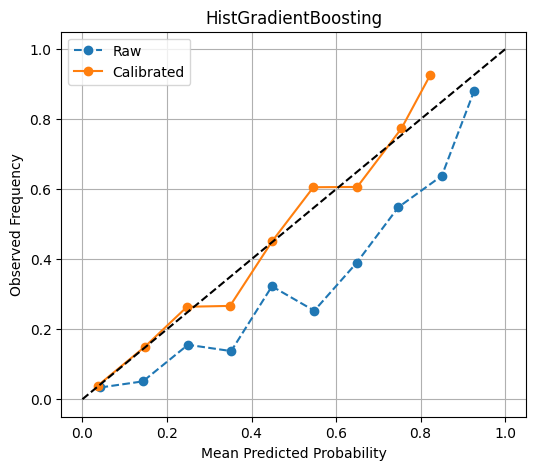

2026/02/27 13:48:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Calibrating XGBoost...


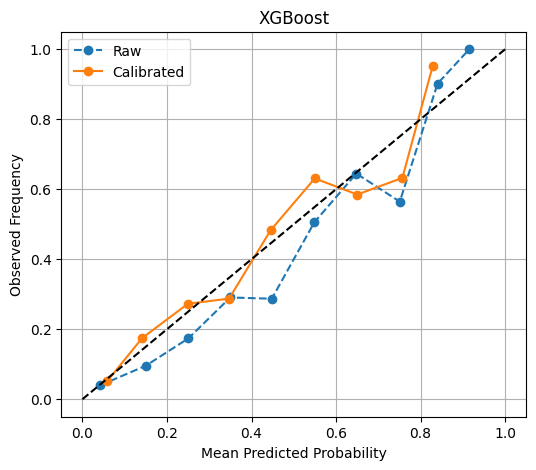

2026/02/27 13:48:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Calibrating LightGBM...


c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: U

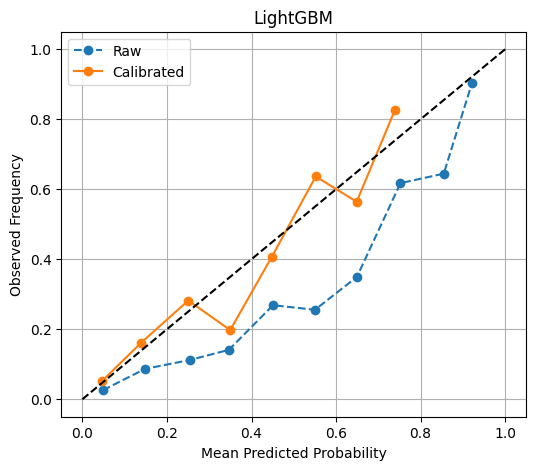

2026/02/27 13:48:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


,PR_AUC,ROC_AUC,Val_Brier
Model,,,
XGBoost,0.687402,0.852536,0.132131
HistGradientBoosting,0.683018,0.847527,0.133178
LightGBM,0.683765,0.848814,0.133806


In [5]:
# cell 5 (Calibration)

calibrated_models = {}
calibration_results = []

top_models = ["HistGradientBoosting", "XGBoost", "LightGBM"]

for model in top_models:

    with mlflow.start_run(run_name=f"calibrated_{model}"):

        print(f"\nCalibrating {model}...")

        base_model = tuned_best_pipelines[model]

        calibrated = CalibratedClassifierCV(
            FrozenEstimator(base_model),
            method="sigmoid"
        )

        calibrated.fit(X_val, y_val)

        # store calibrated model
        calibrated_models[model] = calibrated

        # calibrated probabilities
        probs = calibrated.predict_proba(X_val)[:, 1]

        pr_auc = average_precision_score(y_val, probs)
        roc_auc = roc_auc_score(y_val, probs)
        brier = brier_score_loss(y_val, probs)

        calibration_results.append({
            "Model": model,
            "PR_AUC": pr_auc,
            "ROC_AUC": roc_auc,
            "Val_Brier": brier
        })

        # Calibration plot PER MODEL

        raw_probs = base_model.predict_proba(X_val)[:,1]

        frac_raw, mean_raw = calibration_curve(y_val, raw_probs, n_bins=10)
        frac_cal, mean_cal = calibration_curve(y_val, probs, n_bins=10)

        fig, ax = plt.subplots(figsize=(6,5))

        ax.plot(mean_raw, frac_raw, linestyle="--", marker="o", label="Raw")
        ax.plot(mean_cal, frac_cal, marker="o", label="Calibrated")
        ax.plot([0,1], [0,1], "k--")

        ax.set_title(model)
        ax.set_xlabel("Mean Predicted Probability")
        ax.set_ylabel("Observed Frequency")
        ax.grid(True)
        ax.legend()

        plt.show()

        mlflow.log_param("model_type", model)
        mlflow.log_param("calibration_method", "sigmoid")

        mlflow.log_metric("val_pr_auc", pr_auc)
        mlflow.log_metric("val_roc_auc", roc_auc)
        mlflow.log_metric("val_brier_score", brier)

        mlflow.log_figure(fig, f"{model}_calibration_plot.png")
        mlflow.sklearn.log_model(calibrated, name="calibrated_model")

calibration_df = (
    pd.DataFrame(calibration_results)
      .set_index("Model")
      .sort_values("Val_Brier", ascending=True)
)

display(calibration_df)

## Threshold optimization

,precision,recall,threshold
0,0.4504,0.9039,0.1172
1,0.5000,0.8505,0.1791
2,0.5504,0.7580,0.2837
3,0.6012,0.7082,0.3436
4,0.6511,0.6441,0.4154
5,0.7005,0.5160,0.5296
6,0.7521,0.3238,0.6833


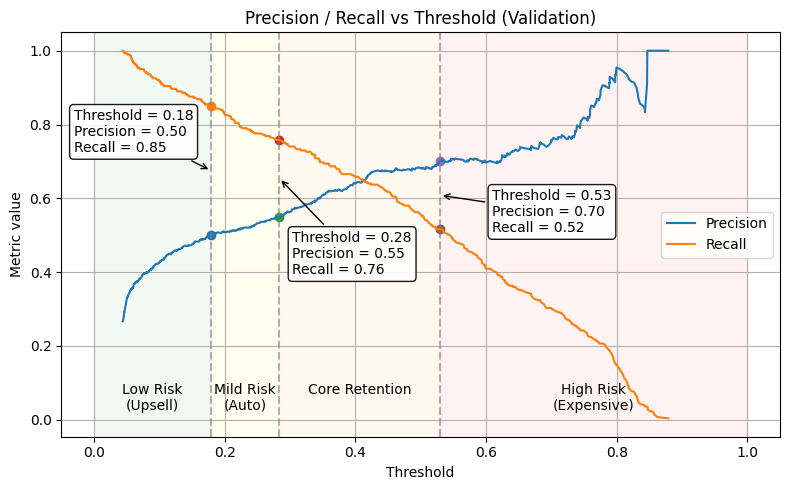

In [6]:
# cell 6 (Threshold optimization)

final_model_name = "XGBoost"
final_model = calibrated_models[final_model_name]

val_probs = final_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)

# precision & recall are length N+1, thresholds length N
precision = precision[:-1]
recall = recall[:-1]

df_thresh = pd.DataFrame({
    "recall": recall,
    "precision": precision,
    "threshold": thresholds
})

TARGET_PRECISIONS = [0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

threshold_results = []

for p in TARGET_PRECISIONS:

    valid = df_thresh[df_thresh["precision"] >= p]

    if valid.empty:
        print(f"\nNo threshold found for precision >= {p}")
        continue

    # pick row with max recall under this precision constraint
    best_row = valid.loc[valid["recall"].idxmax()]

    threshold_results.append({
        "precision": best_row["precision"],
        "recall": best_row["recall"],
        "threshold": best_row["threshold"]
    })

df_results = pd.DataFrame(threshold_results)
display(df_results.round(4))


best_thresholds = [0.1791, 0.2837, 0.5296]

plt.figure(figsize=(8,5))

plt.plot(df_thresh["threshold"], df_thresh["precision"], label="Precision")
plt.plot(df_thresh["threshold"], df_thresh["recall"], label="Recall")

# 4 ACTION REGIONS
t1, t2, t3 = sorted(best_thresholds)

# Region 1: Low risk (No action / upsell)
plt.axvspan(0, t1, color="green", alpha=0.05)

# Region 2: Mild risk (Cheap automated actions)
plt.axvspan(t1, t2, color="yellow", alpha=0.06)

# Region 3: Core retention
plt.axvspan(t2, t3, color="orange", alpha=0.06)

# Region 4: High risk (Expensive actions)
plt.axvspan(t3, 1, color="red", alpha=0.05)

# DYNAMIC REGION LABELS
y_top = 0.1

r1_center = t1 / 2
r2_center = (t1 + t2) / 2
r3_center = (t2 + t3) / 2
r4_center = (t3 + 1) / 2

plt.text(r1_center, y_top, "Low Risk\n(Upsell)", ha="center", va="top")
plt.text(r2_center, y_top, "Mild Risk\n(Auto)", ha="center", va="top")
plt.text(r3_center, y_top, "Core Retention", ha="center", va="top")
plt.text(r4_center, y_top, "High Risk\n(Expensive)", ha="center", va="top")

# Explicit (dx, dy) placements for clean layout
placements = [
    (-0.21,  0.05),
    (0.02, -0.26),
    (0.08,  -0.1)
]

for t, (dx, dy) in zip(best_thresholds, placements):

    idx = (df_thresh["threshold"] - t).abs().idxmin()

    best_p = df_thresh.loc[idx, "precision"]
    best_r = df_thresh.loc[idx, "recall"]

    mid_y = (best_p + best_r) / 2

    plt.axvline(t, linestyle="--", color="gray", alpha=0.6)
    plt.scatter(t, best_p)
    plt.scatter(t, best_r)

    plt.annotate(
        f"Threshold = {t:.2f}\n"
        f"Precision = {best_p:.2f}\n"
        f"Recall = {best_r:.2f}",
        xy=(t, mid_y),
        xytext=(t + dx, mid_y + dy),
        arrowprops=dict(arrowstyle="->", lw=1),
        bbox=dict(boxstyle="round", fc="white", alpha=0.9)
    )

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision / Recall vs Threshold (Validation)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Final evaluation (Test set)

,PR_AUC,ROC_AUC,Recall,Precision,F1
Threshold,,,,,
0.1791,0.6102,0.8312,0.8357,0.4785,0.6086
0.2837,0.6102,0.8312,0.7250,0.5413,0.6198
0.5296,0.6102,0.8312,0.4679,0.6121,0.5304



Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.8868    0.7781    0.8289       775
           1     0.5413    0.7250    0.6198       280

    accuracy                         0.7640      1055
   macro avg     0.7140    0.7515    0.7244      1055
weighted avg     0.7951    0.7640    0.7734      1055



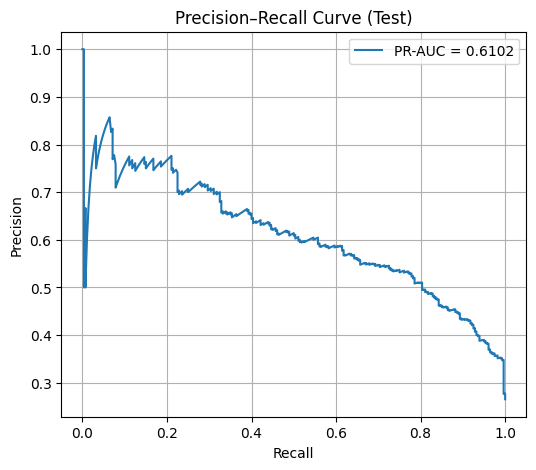

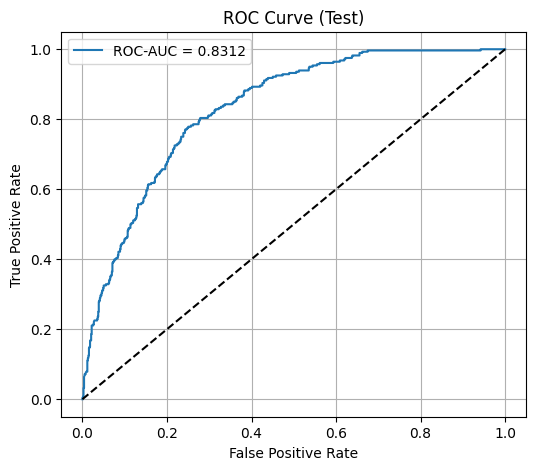

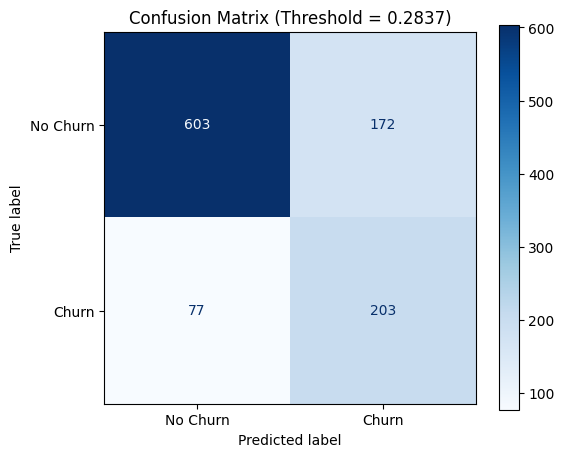

,Metric,Value
0,Total Customers,1055.000
1,Actual Churners,280.000
2,Churn Rate,0.265
3,Customers Flagged,375.000
4,% Customers Contacted,0.355
5,True Churners Captured,203.000
6,Churn Capture Rate (Recall),0.725
7,Campaign Precision,0.541
8,False Positives,172.000
9,Missed Churners,77.000


c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/02/27 13:48:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can

2026/02/27 13:48:42 INFO mlflow.models.model: Found the following environment variables used during model inference: [HUGGINGFACEHUB_API_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.
Successfully registered model 'ChurnModel'.
Created version '1' of model 'ChurnModel'.


Model package saved to c:\Users\arjun\OneDrive\Documents\GitHub\saas-churn-ml-system\artifacts\churn_model_package.joblib


In [7]:
# cell 7 (Final evaluation on Test set)

FINAL_THRESHOLDS = [0.1791, 0.2837, 0.5296]

with mlflow.start_run(run_name="production_evaluation"):

    test_probs = final_model.predict_proba(X_test)[:, 1]

    # AUC metrics (threshold independent)
    pr_auc = average_precision_score(y_test, test_probs)
    roc_auc = roc_auc_score(y_test, test_probs)

    mlflow.log_metric("test_pr_auc", pr_auc)
    mlflow.log_metric("test_roc_auc", roc_auc)

    rows = []

    for t in FINAL_THRESHOLDS:

        test_preds = (test_probs >= t).astype(int)

        rows.append({
            "Threshold": t,
            "PR_AUC": pr_auc,
            "ROC_AUC": roc_auc,
            "Recall": recall_score(y_test, test_preds),
            "Precision": precision_score(y_test, test_preds),
            "F1": f1_score(y_test, test_preds),
        })

    results_df = (
        pd.DataFrame(rows)
        .set_index("Threshold")
        .round(4)
    )

    display(results_df)


    FINAL_THRESHOLD = FINAL_THRESHOLDS[1]

    mlflow.log_param("production_threshold", FINAL_THRESHOLD)

    test_preds = (test_probs >= FINAL_THRESHOLD).astype(int)

    mlflow.log_metric("test_precision", precision_score(y_test, test_preds))
    mlflow.log_metric("test_recall", recall_score(y_test, test_preds))
    mlflow.log_metric("test_f1", f1_score(y_test, test_preds))

    print("\nClassification Report (Test Set):\n")
    print(classification_report(y_test, test_preds, digits=4))

    # PR + ROC
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_probs)
    fpr, tpr, _ = roc_curve(y_test, test_probs)

    # Precision–Recall Curve
    fig_pr, ax_pr = plt.subplots(figsize=(6,5))

    ax_pr.plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.4f}")
    ax_pr.set_title("Precision–Recall Curve (Test)")
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.legend()
    ax_pr.grid(True)

    plt.show()
    mlflow.log_figure(fig_pr, "pr_curve_test.png")

    # ROC Curve
    fig_roc, ax_roc = plt.subplots(figsize=(6,5))

    ax_roc.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    ax_roc.plot([0, 1], [0, 1], "k--")
    ax_roc.set_title("ROC Curve (Test)")
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.legend()
    ax_roc.grid(True)

    plt.show()
    mlflow.log_figure(fig_roc, "roc_curve_test.png")

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_preds)

    fig_cm, ax_cm = plt.subplots(figsize=(6,5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    ).plot(cmap="Blues",  ax=ax_cm)

    ax_cm.set_title(f"Confusion Matrix (Threshold = {FINAL_THRESHOLD})")

    plt.show()
    mlflow.log_figure(fig_cm, "confusion_matrix_test.png")

    # Confusion matrix values
    tn, fp, fn, tp = cm.ravel()

    total_customers = len(y_test)
    actual_churners = y_test.sum()
    predicted_churners = tp + fp

    churn_rate = actual_churners / total_customers
    capture_rate = tp / actual_churners
    precision_campaign = tp / predicted_churners
    contact_rate = predicted_churners / total_customers

    churn_stats = pd.DataFrame({
        "Metric": [
            "Total Customers",
            "Actual Churners",
            "Churn Rate",
            "Customers Flagged",
            "% Customers Contacted",
            "True Churners Captured",
            "Churn Capture Rate (Recall)",
            "Campaign Precision",
            "False Positives",
            "Missed Churners"
        ],
        "Value": [
            total_customers,
            actual_churners,
            round(churn_rate, 3),
            predicted_churners,
            round(contact_rate, 3),
            tp,
            round(capture_rate, 3),
            round(precision_campaign, 3),
            fp,
            fn
        ]
    })

    display(churn_stats)

    # Model serialization

    model_package = {
        "model": final_model,
        "thresholds": {
            "aggressive": 0.1791,
            "balanced": 0.2837,
            "conservative": 0.5296
        },
        "metrics": {
            "roc_auc": float(roc_auc),
            "pr_auc": float(pr_auc)
        },
        "trained_on": datetime.now(timezone.utc).isoformat()
    }

    signature = infer_signature(
        X_test, 
        test_probs
    )

    mlflow.sklearn.log_model(
        final_model,
        name="model",
        registered_model_name="ChurnModel",
        signature=signature,
        input_example=X_test.iloc[:5]
    )

joblib.dump(model_package, MODEL_PATH)

print(f"Model package saved to {MODEL_PATH}")